In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from  torchvision import datasets,transforms

from torch.utils.data import DataLoader, Dataset

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from torchvision import datasets, transforms, utils


In [ ]:
!pip install kaggle

In [ ]:
# configuring the path of Kaggle.json file
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d kabilan03/dogbreedclassification


Dataset URL: https://www.kaggle.com/datasets/kabilan03/dogbreedclassification
License(s): unknown
dogbreedclassification.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
!ls

 archive.zip		     dogbreedclassification.zip   sample_data
'Dog Breed Classification'   kaggle.json


In [ ]:
# extracting the compressed dataset
from zipfile import ZipFile

dataset = '/content/dogbreedclassification.zip'

with ZipFile(dataset, 'r') as zip:
  zip.extractall()
  print('The dataset is extracted')

The dataset is extracted


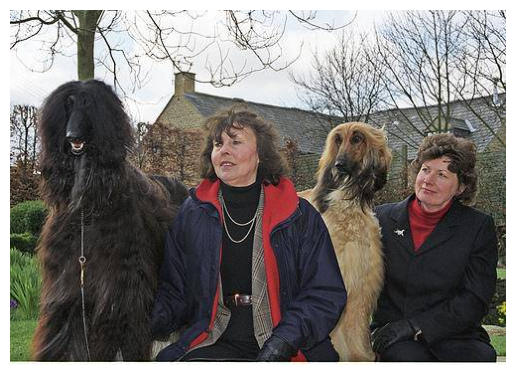

In [ ]:

img = mpimg.imread('/content/Dog Breed Classification/test/afghan_hound/afghan_hound13.jpg')


plt.imshow(img)
plt.axis('off')
plt.show()

In [ ]:
transform=transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,),(0.5,)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomRotation(15),
    transforms.RandomResizedCrop(128, scale=(0.8, 1.0))

    ])

In [ ]:
train_dataset=datasets.ImageFolder(root='/content/Dog Breed Classification/train',transform=transform)
test_dataset=datasets.ImageFolder(root='/content/Dog Breed Classification/test',transform=transform)

In [ ]:
from torch.utils.data import DataLoader

batch_size = 64 # You can adjust this value

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [ ]:
num_classes=len(train_dataset.classes)
print(num_classes)

93


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from  torchvision import datasets,transforms

from torch.utils.data import DataLoader, Dataset

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from torchvision import datasets, transforms, utils

#Building the CNN models

class  CNN(nn.Module):
  def __init__(self):
    super(CNN,self).__init__()

    self.conv1=nn.Conv2d(in_channels=3,out_channels=16,kernel_size=3,stride=1,padding=1)
    self.relu=nn.ReLU()
    self.pool=nn.MaxPool2d(kernel_size=2,stride=2)

    self.conv2=nn.Conv2d(in_channels=16,out_channels=32,kernel_size=3,stride=1,padding=1)

    self.conv3=nn.Conv2d(in_channels=32,out_channels=64,kernel_size=3,stride=1,padding=1)


    self.fc1=nn.Linear(64*16*16,128)
    self.fc2=nn.Linear(128,num_classes)
    self.dropout=nn.Dropout(0.25)


  def forward(self,x):
    x=self.conv1(x)
    x=self.relu(x)
    x=self.pool(x)
    x=self.conv2(x)
    x=self.relu(x)
    x=self.pool(x)
    x=self.conv3(x)
    x=self.relu(x)
    x=self.pool(x)
    x=x.view(x.size(0),-1)
    x=self.fc1(x)
    x=self.relu(x)

    x=self.fc2(x)
    x=self.dropout(x)

    return x

In [ ]:
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device


device(type='cpu')

In [ ]:
model= CNN().to(device)
print(model)

CNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu): ReLU()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=16384, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=93, bias=True)
  (dropout): Dropout(p=0.25, inplace=False)
)


In [ ]:
criterion=nn.CrossEntropyLoss()
optimizer=optim.Adam(model.parameters(),lr=0.001)


In [ ]:
epochs=10


for epoch in range(epochs):
  model.train()
  running_loss=0.0


  for images,labels in train_loader:
    images,labels=images.to(device),labels.to(device)

    outputs=model(images)

    loss=criterion(outputs,labels)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    running_loss+=loss.item()


  avg_loss=running_loss/len(train_loader)



print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")




Epoch [10/10], Loss: 4.5349


In [ ]:
model.eval()

correct=0
total=0


with torch.no_grad():
  for images,labels in test_loader:
    images,labels=images.to(device),labels.to(device)
    outputs=model(images)

    _,predicted=torch.max(outputs,1)
    total+=labels.size(0)
    correct+=(predicted==labels).sum().item()

accuracy=100*correct/total
print(f"Test Accuracy: {accuracy:.2f}%")


Test Accuracy: 1.13%


In [ ]:
from PIL import Image
import torch
import matplotlib.pyplot as plt

image_path="/content/Dog Breed Classification/test/bernese_mountain_dog/bernese_mountain_dog15.jpg"

image = Image.open(image_path).convert("RGB")
image = transform(image)          # [3, H, W]
image = image.unsqueeze(0)        # [1, 3, H, W]


model.to(device)
model.eval()

image = image.to(device)


In [ ]:
with torch.no_grad():
    outputs = model(image)
    _, predicted = torch.max(outputs, 1)


In [ ]:
class_names = test_dataset.classes

predicted_class = class_names[predicted.item()]
print("Predicted class:", predicted_class)


In [1]:
torch.save(model.state_dict(), '/Backend/model.pth')

NameError: name 'torch' is not defined